# GPT Finally!

## 1. But what really stand for GPT?
<div class='alert alert-block alert-info'>
A Generative Pre‑trained Transformer (GPT) is a type of large language model built on the transformer architecture, trained on massive amounts of text data to learn patterns of language. After pre‑training, it can generate coherent text, answer questions, and perform many language tasks by predicting the next word in a sequence.
</div>

## 2. Configuration
Here is the configuration of GPT-2 (124M parameters). Those are `hyperparameters` that can be played with.

In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

## 3. **THE BUILDING BLOCKS OF GPT**
- ## Layer Normalization


In [2]:
import torch
import torch.nn as nn

In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        # They are registered to be model parameters, that the optimizer will update them while training
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.ones(emb_dim))

    def forward(self,x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True)
        norm_x = (x-mean)/torch.sqrt(var+self.eps) #Avoid division by 0.
        return self.scale * norm_x + self.shift

It basically changes the **variance** of batch input to 1 and the **mean** to 0. 

This can help alleviate the effect of **gradient explosion** or **vanishing gradient**, also speeding up **convergence**.

`torch.nn.Parameter` is a special kind of tensor in PyTorch that tells the framework *“this is a trainable parameter of the model.”* When you assign a `Parameter` inside an `nn.Module`, it is automatically registered so that `model.parameters()` and optimizers know to update it during training.  

In the `LayerNorm` example, the `scale` (γ) and `shift` (β) are defined as `Parameter`s. That means they will be learned during training, allowing the model to adjust the normalized values flexibly instead of always keeping them fixed. Without `Parameter`, they would just be static tensors and never change.

-  ## Activation Function

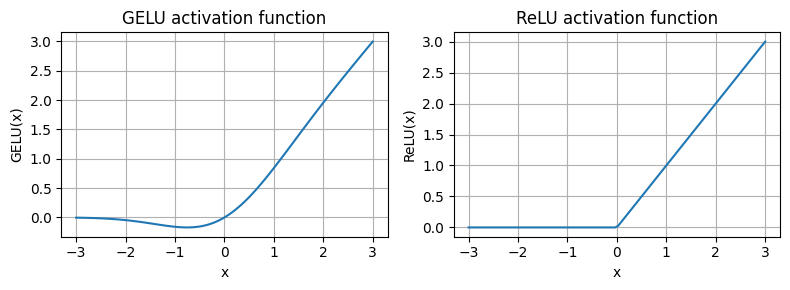


<div class="alert alert-block alert-info">

As we can see in the resulting plot, ReLU is a piecewise linear function that
outputs the input directly if it is positive; otherwise, it outputs zero. 

GELU is a smooth, nonlinear function that approximates ReLU but with a non-zero gradient for negative values.
</div>

<div class="alert alert-block alert-warning">

The smoothness of GELU, as shown in the above figure, can lead to better optimization properties
during training, as it allows for more nuanced adjustments to the model's parameters. 

In contrast, ReLU has a sharp corner at zero, which can sometimes make optimization harder,
especially in networks that are very deep or have complex architectures. 

Moreover, unlike RELU, which outputs zero for any negative input, GELU allows for a small, non-zero output
for negative values. 

This characteristic means that during the training process, neurons that
receive negative input can still contribute to the learning process, albeit to a lesser extent
than positive inputs.

</div>

In [7]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self,x):
        return 0.5*x*(
            1 + torch.tanh(
                torch.sqrt(
                    (torch.tensor(2/torch.pi))
                ) * (x + 0.044715 * torch.pow(x,3))
            )
        )

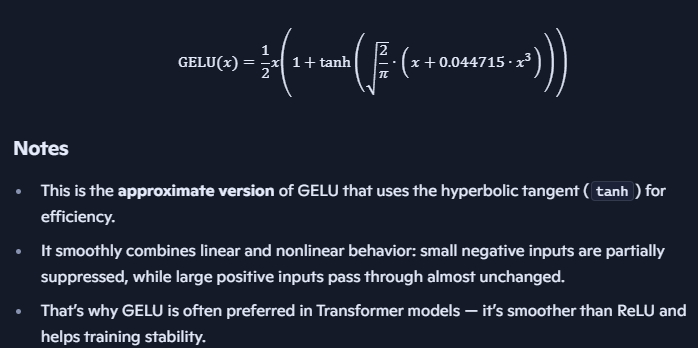

- ## Feed Forward Neural Network